<div style="height:80px; display:flex;"><img src='data:image/svg+xml;utf8,<svg xmlns="http://www.w3.org/2000/svg" width="290" height="145"><path d="M44.7 74q-6-2.5-6.3-5.5c.2-2.5 2-3.4 5.4-2.9.1.4.3 1.1.3 2q.5 4.5 3.4 4.5 3-.3 3.3-6-.6-7-10-7-8.4 1-10 11.3-.3 3.5 7.5 7a23.6 23.6 0 0 1 4.3 2.5 9.4 9.4 0 0 1-6 1 17.3 17.3 0 0 1-7-2.3q-.8 6 10 6 10-.7 10.7-5.4 0-2.7-5.7-5zm25-7c-.2-.8-1-1.3-3-1.7q-2.7-.4-3.3-1 5.6-2 6-6.6 0-9.6-10-10a17 17 0 0 0-2.5.3 10 10 0 0 1-1.5.1 6 6 0 0 1-1.7-.4 9 9 0 0 0-2.7-.6q-3-.3-6.7 3.4a4.5 4.5 0 0 1 3 4l-.4 4A8 8 0 0 1 51 61.7a10 10 0 0 1 .4 8.7 6 6 0 0 1-.8 1.4c2.2-.2 3.3-1 3.4-2 0-.2 0-.6-0-1.4a11.3 11.3 0 0 1-.3-1.6v-.6a8.7 8.7 0 0 1 0-2.2c.4.2 1.2.8 2.3 1.6q7.6 5.6 10.6 5.6 3.6-.7 3-4zm-10-6.6a31 31 0 0 1-5.7.4 27 27 0 0 1 .4-4.6c0-0 0-.6.1-1.5l.1-1.4q7.7-2 8.6 1.6-0 4.4-3.5 5.5zm-30 6.7a13.6 13.6 0 0 1 6-8.5 11 11 0 0 0-5-6.6q-7-3.5-12.7-.3-6 5-6 13.4.2 8.6 11.7 9A15 15 0 0 0 30 73a7.4 7.4 0 0 1-.2-5.7zm-4.4 2.3q-5.6.6-6.7-4-.4-8 6-10 4 0 5.3 4.3a9.4 9.4 0 0 1-.6 6c-1 2-2 3.4-4 4zm22.4 26.7a31 31 0 0 1-29-20 13.4 13.4 0 0 1-5-2.4 9.5 9.5 0 0 1-1.5-1.4A39.7 39.7 0 0 0 77.6 98a47 47 0 0 0 .5-6.7A26 26 0 0 0 75.4 79a31 31 0 0 1-27.7 17z" fill="%23e76711"/><path d="M91.5 68A39.7 39.7 0 0 0 16 50.5a12 12 0 0 1 6-2.6 31 31 0 0 1 54.7 27.7c.1.1.1.2.2.3 2 3 4 8 4 15.5 0 1 0 2-0 3.4a39.6 39.6 0 0 0 10.6-27z" fill="%23bf1a20"/><text font-size="36" text-anchor="middle" x="178" y="68">OSR Lab</text><text font-size="14" text-anchor="middle" x="178" y="99">Open Security Research</text></svg>'/><div><span style="font-size:30pt; color:#666666;">Side-Channel Acquisition Software</span></div></div><img src='data:image/svg+xml;utf8,<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 500 3"><linearGradient id="g" x1="0" y1="0" x2="100%" y2="0"><stop offset="0" stop-color="%23e76711"/><stop offset="1" stop-color="%23bf1a20"/></linearGradient><rect width="500" height="3" rx="1" fill="url(%23g)"/></svg>' style="width:100%;height:8px;"/>

# Side-Channel Acquisition with the OSR-FPGA-A7100T Board and a pico3000

## 1. Acquisition Environment Setup

Side-channel acquisition requires a PC, the target-of-evaluation (TOE) development board and an oscilloscope.
The PC communicates with the TOE, while the oscilloscope records the power consumption / electromagnetic radiation during the cryptographic operation.

The PC needs to:
1. Configure the oscilloscope acquisition parameters
2. Read the sampled data from the oscilloscope

<img src="images/sca-acquire.png" width='800'></img>

### 🛠️ Acquisition Setup

- 💻 Host PC: sends the AES plaintext (16 bytes) over the serial port
- 📟 TOE board: the OSR-FPGA-A7100T development board. The host sends 32 bytes (16-byte key + 16-byte plaintext), the board runs the AES encryption operation and returns the 16-byte AES ciphertext over the serial port. This example uses the [Vivado AES project](https://github.com/OSR-Lab/OSR-FPGA-A7100T/tree/main/projects/aes) provided with the board.
- 📡 Oscilloscope: this example uses a `PICO3206D`. The oscilloscope module is integrated into the `nuscar.collect.Scope` class, and this example is implemented with the [pico3000 Python control package](https://github.com/OSR-Lab/pico3000): download a pico3000 release, pip install it, and then import the library when you use it.

<img src="../images/fpga_sca.png" width='650px'></img>

+ Trigger: connect the OSR-FPGA-A7100T trigger output Trigger_OUT/AB20 to oscilloscope channel 1.
+ Acquisition: connect the OSR-FPGA-A7100T power collection port JP3 to the input of the signal amplifier, and the amplifier output to oscilloscope channel 2 (a 50-ohm impedance-matching connection is also required).

## 2. Serial Communication Module

The communication module is implemented by the nuscar.collect.Communicator class; users subclass this base class to implement communication between the PC and the `TOE`. The base class is defined as follows:

```python
class OSRTOE(Communicator):
    """Communication with TOE"""
    @abstractmethod
    def get_metadata(self, meta_index=0):
        pass
    @abstractmethod
    def close_device(self):
        pass
```

Users need to implement the `get_metadata` and `close_device` methods.

- `get_metadata` performs the communication with the `TOE`, collects the `meta` information such as the command sent and the data returned, and assembles the communication data of the trace being acquired; inside the framework's acquisition loop, `meta_index` identifies the index of the current `Trace`.</br>
   The method must return a dictionary whose `value`s are of type `bytes`.
   For example:
   ```python
       {'plaintext':b'\x00\x01\x02\x03\x04\x05', 'ciphertext':b'\xce\x23\x32\x43\xae\x01'}
   ```
- `close_device` closes the device

The trigger signal is emitted while `get_metadata` runs.

Because devices such as serial ports can only be held by one instance at a time, reopening the same device makes this class automatically call close_device on the previous instance.

In [11]:
# Import the required libraries
import nuscar
import serial
from nuscar.collect import Communicator, Scope
import time
import os
import numpy as np

In [12]:
class OSRTOE(Communicator):
    def __init__(self, com):
        super().__init__()
        self.dev = serial.Serial(com, 115200, timeout=1)  # Open the serial port, port number is com (e.g. 'com2'), baud rate is 115200
        
    def get_metadata(self, meta_index=0):
        # plaintext = bytes.fromhex('000102030405060708090a0b0c0d0e0f31323334353637383132333435363738') # 16-byte key + 16-byte plaintext
        key = bytes.fromhex('000102030405060708090a0b0c0d0e0f')
        plaintext = os.urandom(16) # random 16-byte plaintext
        text = key + plaintext
        self.dev.write(text)
        ciphertext = self.dev.read(16)
        return {'key': key ,'plaintext': plaintext, 'ciphertext': ciphertext}
        
    def close_device(self):
        self.dev.close()

**You can check the device's port number in Device Manager**

In [13]:
dev = OSRTOE('com6') # Second open, automatically closes dev0

2026-05-13 18:24:08,333 - nuscar.collect - WARNING - Automatically closing already instantiated Communicator


In [15]:
dev.get_metadata()

{'key': b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\x0c\r\x0e\x0f',
 'plaintext': b'1\xd6\xa1\xdc\xb4hA\x89\x92\xf9\xc1\xf4\xc2\xd0#\x88',
 'ciphertext': b'b\x18\x95\xd1\x8d*\x17o2o\x12az]\xa1\xec'}

In [5]:
# dev.close_device()

In [52]:
# Verify the meta data once
from nuscar.ciphers import aes
pc = dev.get_metadata()
plaintext = np.frombuffer(pc['plaintext'], dtype = np.uint8)
ciphertext = np.frombuffer(pc['ciphertext'], dtype = np.uint8)
key = np.frombuffer(pc['key'], dtype = np.uint8)
c_correct = aes.encrypt(plaintext, key)
ciphertext == c_correct

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True]])

## 3. Oscilloscope Initialisation and Parameters

**Oscilloscope implementation**
  1. Download the [pico3000 Python control package](https://github.com/OSR-Lab/pico3000) locally
  2. import pico3000
  3. Integrate pico3000 into the `nuscar.collect.Scope` class
  4. Set the oscilloscope parameters (the parameters recorded while debugging with picoscope in the previous steps)

In [16]:
import pico3000
from nuscar.collect import Scope

In [17]:
class PicoScope(Scope):
    def __init__(self):
        self.dev = pico3000.Pico3000A()
    
    @property
    def sequence_num(self):
        return self.dev._sequence
        
    def arm(self):
        return self.dev.arm()

    def acquire_samples(self): 
        return [self.dev.acquire(pico3000.CHANNEL.CHANNELB)]  # Acquire channel B only

    def close(self):
        self.dev.close()

In [18]:
scope = PicoScope()

2026-05-13 18:24:35,421 - pico3000 - INFO - device <JZ227/0051> opened


In [19]:
# Configure channel A
scope.dev.set_channel(
    channel=pico3000.CHANNEL.CHANNELA, 
    coupling=pico3000.COUPLING.DC,
    vrange=pico3000.VRANGE.PICO_5V,
    offset=0,
    enable=True,
    acquire=True
)

In [20]:
# Configure channel B
scope.dev.set_channel(
    channel=pico3000.CHANNEL.CHANNELB, 
    coupling=pico3000.COUPLING.AC,
    vrange=pico3000.VRANGE.PICO_100MV,
    offset=0.0,
    enable=True,
    acquire=True
)

In [21]:
# Configure the trigger
scope.dev.set_trigger(
    source=pico3000.CHANNEL.CHANNELA,
    threshold=1000, # mv
    delay=0
)

In [37]:
# Configure the acquisition
pico3000.timebase_to_sample_rate(2)
scope.dev.set_acquire(
    pre_trigger=100,
    post_trigger=1600,
    timebase=1, # the sample rate of a timebase can be computed with the timebase_to_sample_rate function
    sequence=1
)

2026-05-13 18:25:49,651 - pico3000 - INFO - sample rate set to 500.000000 MHz


In [38]:
scope.arm()

True

In [39]:
dev.get_metadata()

{'key': b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\x0c\r\x0e\x0f',
 'plaintext': b'\xfa\xcd5\xfaA\x12\xe2\x9bvQ\xbf\xfe\x87\xa6Z\xaf',
 'ciphertext': b'\xa6\xcb\x1bfj\xae\xc9T\xc2\xa5\xb1\xa9\xd1\x94pR'}

In [40]:
sa = scope.dev.acquire(pico3000.CHANNEL.CHANNELA)
sb = scope.dev.acquire(pico3000.CHANNEL.CHANNELB) 

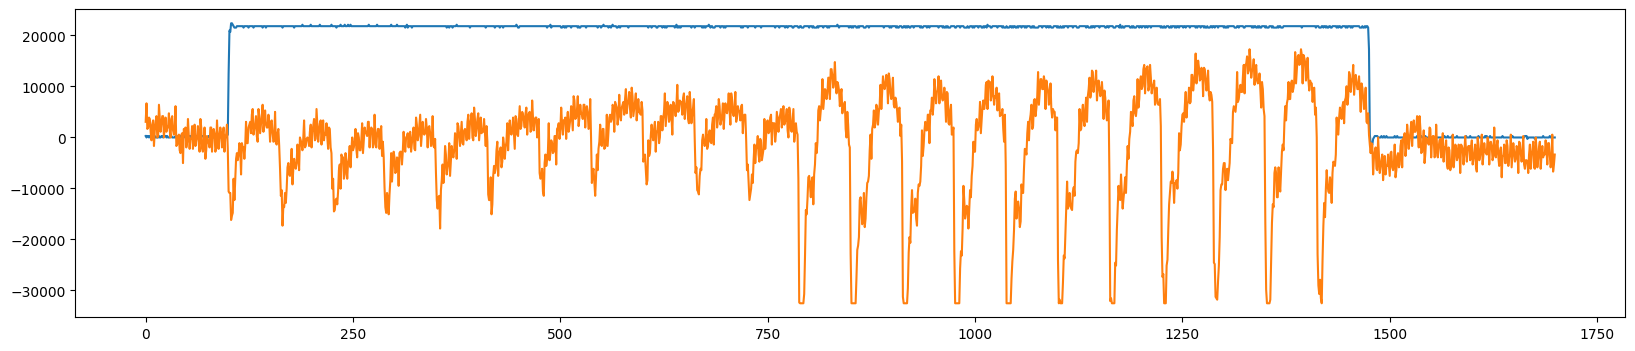

In [41]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [20,4]  # Adjust the figure size
plt.plot(sa.T)
plt.plot(sb.T)
plt.show()

## 4. Trace Acquisition Module

### 4.1 The nuscar.collect.CollectTask class
The trace acquisition module is implemented by the nuscar.collect.CollectTask class
-**Parameters:**
+ scope: the configured oscilloscope
+ dev: the configured TOE communication
+ predelay: the time between arming and the first trigger. Some oscilloscopes need to wait for a while after arming before they can trigger, so predelay controls the delay from arm to the first trigger
+ postdelay
+ viewfreq: how many sequences to acquire between displays

In [42]:
# Instantiate the trace acquisition task
task = nuscar.collect.CollectTask(scope, dev, retry=100, predelay=1e5, postdelay=1e7, viewfreq=2) 

### 4.2 Acquisition Test

In [43]:
ctn = task.check(10) # Acquire 20 sequences as a test; the results are stored in a temporary container

0 Collection progress:    0% 0/10 Elapsed: 00:00 Remaining: ? Speed: ? Sequence(s)/s

FigureWidgetResampler({
    'data': [{'hoverinfo': 'name+x+y',
              'line': {'color': '#636EFA'},
              'name': '<b style="color:sandybrown">[R]</b> trace 0 <i style="color:#fc9944">~2</i>',
              'opacity': 0.8,
              'type': 'scattergl',
              'uid': '39baf259-5f08-4cc1-bd40-f703fb1dbb30',
              'x': array([   0,    1,    2, ..., 1695, 1698, 1699], shape=(1000,)),
              'y': array([-3905,  -836,     0, ..., -3068,  1115, -3905],
                         shape=(1000,), dtype=int16)}],
    'layout': {'height': 400,
               'hovermode': 'x unified',
               'plot_bgcolor': 'white',
               'template': '...',
               'title': {'text': 'Trace 0 @ channel 0'},
               'xaxis': {'gridcolor': 'lightgrey', 'mirror': True, 'showline': True, 'ticks': 'outside'},
               'yaxis': {'gridcolor': 'lightgrey', 'mirror': True, 'showline': True, 'ticks': 'outside'}}
})

In [44]:
ctn

Trace Count,Sample Points,Meta Info
10,1700,"['key', 'plaintext', 'ciphertext']"


In [45]:
ctn.view()

FigureWidget({
    'data': [{'hoverinfo': 'name+x+y',
              'line': {'color': '#636EFA'},
              'name': '0',
              'opacity': 0.8,
              'type': 'scattergl',
              'uid': 'f04b4886-be6d-4eda-910d-c17665b14373',
              'x': array([   0,    1,    2, ..., 1697, 1698, 1699], shape=(1700,)),
              'y': array([ -278,  1115, -4184, ...,  2231,  -836,  2231],
                         shape=(1700,), dtype=int16)},
             {'hoverinfo': 'name+x+y',
              'line': {'color': '#EF553B'},
              'name': '1',
              'opacity': 0.8,
              'type': 'scattergl',
              'uid': 'e041cf75-a2f1-41e4-8a16-7c7892728f09',
              'x': array([   0,    1,    2, ..., 1697, 1698, 1699], shape=(1700,)),
              'y': array([ -278,  1115, -4184, ...,  2231,  -836,  2231],
                         shape=(1700,), dtype=int16)},
             {'hoverinfo': 'name+x+y',
              'line': {'color': '#00CC96'},
    

### 4.3 Acquire and Store Traces

In [46]:
storer = nuscar.StorerZARR('7100-aes.zarr')
task.run(storer, 10000) # You can click stop to end the acquisition early

0 Collection progress:    0% 0/10000 Elapsed: 00:00 Remaining: ? Speed: ? Sequence(s)/s

Button(button_style='danger', description='Stop Collection', icon='stop', style=ButtonStyle())

Output()

FigureWidgetResampler({
    'data': [{'hoverinfo': 'name+x+y',
              'line': {'color': '#636EFA'},
              'name': '<b style="color:sandybrown">[R]</b> trace 0 <i style="color:#fc9944">~2</i>',
              'opacity': 0.8,
              'type': 'scattergl',
              'uid': '6a0d2863-33bb-47b5-be7a-893387a67750',
              'x': array([   0,    1,    3, ..., 1695, 1698, 1699], shape=(1000,)),
              'y': array([ 2231,  7532,  2510, ..., -4742, -1952, -2510],
                         shape=(1000,), dtype=int16)}],
    'layout': {'height': 400,
               'hovermode': 'x unified',
               'plot_bgcolor': 'white',
               'template': '...',
               'title': {'text': 'Trace 0 @ channel 0'},
               'xaxis': {'gridcolor': 'lightgrey', 'mirror': True, 'showline': True, 'ticks': 'outside'},
               'yaxis': {'gridcolor': 'lightgrey', 'mirror': True, 'showline': True, 'ticks': 'outside'}}
})

## 5. Open and View the Stored Traces

In [47]:
reader = nuscar.ReaderZARR('7100-aes.zarr')
ctn = nuscar.ContainerZARR(reader) # Open the acquired traces

In [48]:
ctn

Trace Count,Sample Points,Meta Info
10000,1700,"['key', 'plaintext', 'ciphertext']"


In [49]:
ctn.view()

FigureWidget({
    'data': [{'hoverinfo': 'name+x+y',
              'line': {'color': '#636EFA'},
              'name': '0',
              'opacity': 0.8,
              'type': 'scattergl',
              'uid': '83fcb620-7115-4bd7-9da0-57d878931a11',
              'x': array([   0,    1,    2, ..., 1697, 1698, 1699], shape=(1700,)),
              'y': array([ 2231,  7532,  6974, ..., -3905, -1952, -2510],
                         shape=(1700,), dtype=int16)},
             {'hoverinfo': 'name+x+y',
              'line': {'color': '#EF553B'},
              'name': '1',
              'opacity': 0.8,
              'type': 'scattergl',
              'uid': '0c32a37c-4b98-402c-8e02-a62f312b10a6',
              'x': array([   0,    1,    2, ..., 1697, 1698, 1699], shape=(1700,)),
              'y': array([ 3905,  5579,  5021, ..., -3068, -6695, -5858],
                         shape=(1700,), dtype=int16)},
             {'hoverinfo': 'name+x+y',
              'line': {'color': '#00CC96'},
    

## 6. Close the oscilloscope and TOE connections and the open trace file

In [26]:
scope.close()

2026-03-24 17:46:22,440 - pico3000 - INFO - No trigger
2026-03-24 17:46:22,441 - nuscar.collect - WARNING - Oscilloscope failed to read waveform, please check trigger status, retrying automatically...


In [27]:
dev.close()

In [28]:
storer.close()